# Pipeline Inferensi Terpadu Curah Hujan (XGBoost & LSTM)

Notebook ini berisi seluruh alur prediksi (*inference pipeline*) untuk memprediksi curah hujan secara mandiri (*self-contained*) dengan membandingkan **4 model sekaligus**:
1. **XGBoost (Pre-Trained)**
2. **XGBoost (Fine-Tuned)**
3. **LSTM (Pre-Trained)**
4. **LSTM (Fine-Tuned)**

Rentang tanggal pengujian diselaraskan langsung dengan **data uji asli (*test splits*)** dari fase pelatihan:
- **Tahap Pre-Trained**: `2024-01-01` s.d `2025-12-31` (Menggunakan input satelit GSMaP)
- **Tahap Fine-Tuned**: `2026-04-06` s.d `2026-05-31` (Menggunakan input AWS stasiun bumi)

Perbandingan disajikan dalam bentuk:
- **Tabel Metrik Komparatif 4 Kolom** (metrik klasifikasi, metrik meteorologi BMKG, dan metrik regresi).
- **Plot Time-Series** perbandingan model (XGBoost vs LSTM) untuk masing-masing tahap secara terpisah.
- **Scatter Plot korelasi dan Confusion Matrix** bertumpuk vertikal.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import xgboost as xgb
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, mean_squared_error, mean_absolute_error

# ── KONFIGURASI TARGET WAKTU INFERENSI (DATA UJI ASLI) ──
PRETRAIN_START = '2024-01-01'
PRETRAIN_END   = '2025-12-31'

FINETUNE_START = '2026-04-06'
FINETUNE_END   = '2026-05-31'

# Path Direktori Data dan Model
BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall/Google_Earth_Engine/Data_Satelit')
STATION_FILE  = BASE_DATA_DIR / 'id-05_clear_data_hourly.csv'
ERA5_FILE     = BASE_DATA_DIR / 'ERA5_Hourly_All_Requested_Features_2000_2026.csv'
BASE_MODEL_DIR = Path('D:/Github/Projek_Rainfall/DeepLearning_Satelit')

# Konstanta
RAIN_THRESHOLD = 0.2
LOOKBACK = 24

ERA5_FEATURES_MAPPING = {
    'temperature_era5': 'temperature',
    'humidity_era5': 'humidity',
    'dewpoint_era5': 'dewpoint',
    'rain_mm': 'rainrate',
    'sealevel_pressure_era5': 'pressure',
    'u10_era5': 'era5_u_wind',
    'v10_era5': 'era5_v_wind',
    'cloud_cover_era5': 'era5_cloud_cover',
    'cape_era5': 'era5_cape',
    'total_column_water_vapour_era5': 'era5_tcwv',
    'moisture_divergence_era5': 'era5_moisture_div',
    'direct_radiation_era5': 'era5_direct_rad',
    'sunshine_duration_era5': 'era5_sunshine'
}

# Set style visualisasi premium
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 11

## 0. Fungsi Pembantu Bersama (Common Helpers)

In [2]:
def load_data(station_file, era5_file, start_date=None, end_date=None, stage='finetune'):
    """
    Memuat, menyelaraskan, dan menggabungkan data ERA5 dan AWS Stasiun Bumi
    atau GSMaP seperti pada fase training.
    """
    if not os.path.exists(era5_file):
        raise FileNotFoundError(f"File ERA5 tidak ditemukan di: {era5_file}")
    df_era5 = pd.read_csv(era5_file)
    if 'datetime_utc' in df_era5.columns:
        df_era5['timestamp'] = pd.to_datetime(df_era5['datetime_utc'], utc=True)
    else:
        df_era5['timestamp'] = pd.to_datetime(df_era5['unixtime'], unit='s', utc=True)
    df_era5 = df_era5.set_index('timestamp').sort_index()

    df_merged = df_era5.copy()
    for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
        if raw_col in df_era5.columns:
            df_merged[new_name] = df_era5[raw_col]

    # Penggantian curah hujan ERA5 dengan data GSMaP pada tahap Pre-training
    if stage == 'pretrain':
        gsmap_file = Path(era5_file).parent / 'Rainfall_GSMap_TimeSeries_UNIX.csv'
        if gsmap_file.exists():
            df_gsmap = pd.read_csv(gsmap_file)
            if 'datetime_utc' in df_gsmap.columns:
                df_gsmap['timestamp'] = pd.to_datetime(df_gsmap['datetime_utc'], utc=True)
            else:
                df_gsmap['timestamp'] = pd.to_datetime(df_gsmap['unixtime'], unit='s', utc=True)
            df_gsmap = df_gsmap.set_index('timestamp').sort_index()
            df_gsmap_hourly = df_gsmap[['hourlyPrecipRateGC']].rename(columns={'hourlyPrecipRateGC': 'precipitation'})
            df_merged = df_merged.merge(df_gsmap_hourly, left_index=True, right_index=True, how='left')
            if 'rainrate' in df_merged.columns and 'precipitation' in df_merged.columns:
                df_merged['rainrate'] = df_merged['precipitation'].combine_first(df_merged['rainrate'])
                df_merged = df_merged.drop(columns=['precipitation'])

    # Penggantian data cuaca ERA5 dengan data Stasiun AWS Bumi pada tahap Fine-tuning
    if stage == 'finetune' and station_file and os.path.exists(station_file):
        df_station = pd.read_csv(station_file)
        df_station['timestamp'] = pd.to_datetime(df_station['datetime_utc'], utc=True)
        df_station = df_station.set_index('timestamp').sort_index()
        cols_to_keep = ['temperature', 'humidity', 'pressure', 'dewpoint', 'rainrate']
        df_station = df_station[[c for c in cols_to_keep if c in df_station.columns]]
        df_merged.update(df_station)

    # Pembersihan curah hujan gerimis (drizzle threshold)
    drizzle_thresh = 0.2 if stage == 'pretrain' else 0.1
    if 'rainrate' in df_merged.columns:
        df_merged['rainrate'] = np.where(df_merged['rainrate'] >= drizzle_thresh, df_merged['rainrate'], 0.0)

    selected_features = list(ERA5_FEATURES_MAPPING.values())
    df_merged = df_merged[[c for c in selected_features if c in df_merged.columns]]

    if start_date is None:
        start_date = '2024-01-01' if stage == 'pretrain' else '2026-04-06'
    if end_date is None:
        end_date = '2025-12-31' if stage == 'pretrain' else '2026-05-31'

    start_dt = pd.to_datetime(start_date, utc=True)
    end_dt = pd.to_datetime(end_date, utc=True)
    buffer_start_dt = start_dt - pd.Timedelta(hours=LOOKBACK)

    df_filtered = df_merged[(df_merged.index >= buffer_start_dt) & (df_merged.index <= end_dt)].copy()
    drop_subset = ['temperature'] if 'temperature' in df_filtered.columns else None
    df_hourly = df_filtered.dropna(subset=drop_subset).copy() if drop_subset else df_filtered.dropna().copy()
    df_hourly = df_hourly.select_dtypes(include=[np.number])
    
    return df_hourly, start_dt, end_dt

def load_calibrator_model(path):
    if not os.path.exists(path):
        return None
    try:
        return joblib.load(path)
    except:
        return None

def apply_calibrator_dynamically(calibrator, probs):
    if calibrator is None or len(probs) == 0:
        return probs
    class_name = calibrator.__class__.__name__
    if "IsotonicRegression" in class_name:
        return calibrator.predict(probs)
    elif "LogisticRegression" in class_name or hasattr(calibrator, "predict_proba"):
        return calibrator.predict_proba(probs.reshape(-1, 1))[:, 1]
    else:
        try:
            return calibrator.predict(probs)
        except:
            return probs

def load_model_safe(model_path):
    """
    Keras model loader safe from serialization error.
    """
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")
    
    # Standard try
    try:
        return tf.keras.models.load_model(model_path, compile=False)
    except Exception as e:
        # Clean config from quantization_config
        import zipfile
        import shutil
        
        temp_dir = Path("temp_keras_extract")
        if temp_dir.exists():
            shutil.rmtree(temp_dir)
        temp_dir.mkdir(parents=True, exist_ok=True)
        
        with zipfile.ZipFile(model_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir)
            
        config_json_path = temp_dir / "config.json"
        if config_json_path.exists():
            with open(config_json_path, 'r', encoding='utf-8') as f:
                config = json.load(f)
            
            # Clean recursively
            def clean_config(d):
                if isinstance(d, dict):
                    d.pop('quantization_config', None)
                    for k, v in d.items():
                        clean_config(v)
                elif isinstance(d, list):
                    for item in d:
                        clean_config(item)
            
            clean_config(config)
            with open(config_json_path, 'w', encoding='utf-8') as f:
                json.dump(config, f, indent=4)
                
        cleaned_model_path = Path("cleaned_model.keras")
        with zipfile.ZipFile(cleaned_model_path, 'w', zipfile.ZIP_DEFLATED) as zip_write:
            for root, dirs, files in os.walk(temp_dir):
                for file in files:
                    file_path = Path(root) / file
                    archive_name = file_path.relative_to(temp_dir)
                    zip_write.write(file_path, archive_name)
                    
        shutil.rmtree(temp_dir)
        model = tf.keras.models.load_model(cleaned_model_path, compile=False)
        if cleaned_model_path.exists():
            cleaned_model_path.unlink()
        return model

# Bab 1: Pipeline Inferensi XGBoost

In [3]:
def engineer_features_xgboost(df_base):
    """
    Rekayasa fitur untuk XGBoost (Lags, Tendencies, Cyclic Features)
    """
    df = df_base.copy()
    
    # 1. Fitur Tendency
    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df.columns:
            df[f'{c}_tendency_1h'] = df[c].diff()
            
    # 2. Dewpoint Depression
    if 'temperature' in df.columns and 'dewpoint' in df.columns:
        df['dewpoint_depression'] = df['temperature'] - df['dewpoint']

    # 3. Fitur Siklikal Waktu
    df['sin_hour']  = np.sin(2 * np.pi * df.index.hour / 24.0)
    df['cos_hour']  = np.cos(2 * np.pi * df.index.hour / 24.0)
    df['sin_month'] = np.sin(2 * np.pi * df.index.month / 12.0)
    df['cos_month'] = np.cos(2 * np.pi * df.index.month / 12.0)
    df['sin_doy']   = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    df['cos_doy']   = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

    # 4. Fitur Lag Temporal (1h, 3h, 6h, 12h, 24h)
    lag_vars = ['rainrate', 'temperature', 'humidity', 'pressure', 'dewpoint', 'era5_cloud_cover']
    lags = [1, 3, 6, 12, 24]
    for var in lag_vars:
        if var in df.columns:
            for lag in lags:
                df[f'{var}_lag_{lag}h'] = df[var].shift(lag)
                
    df = df.dropna()
    return df

In [4]:
# Load data untuk tahap Pre-Trained & Fine-Tuned (XGBoost)
df_raw_xgb_pre, start_dt_pre, end_dt_pre = load_data(str(STATION_FILE), str(ERA5_FILE), PRETRAIN_START, PRETRAIN_END, 'pretrain')
df_raw_xgb_pre['target_amount'] = df_raw_xgb_pre['rainrate'].shift(-1)
df_raw_xgb_pre = df_raw_xgb_pre.dropna()
df_features_xgb_pre = engineer_features_xgboost(df_raw_xgb_pre)

df_raw_xgb_fine, start_dt_fine, end_dt_fine = load_data(str(STATION_FILE), str(ERA5_FILE), FINETUNE_START, FINETUNE_END, 'finetune')
df_raw_xgb_fine['target_amount'] = df_raw_xgb_fine['rainrate'].shift(-1)
df_raw_xgb_fine = df_raw_xgb_fine.dropna()
df_features_xgb_fine = engineer_features_xgboost(df_raw_xgb_fine)

# Path model XGBoost
xgb_dir = BASE_MODEL_DIR / "results_xgboost" / "models"

# 1. Load Pre-Trained Models
clf_xgb_pre = joblib.load(xgb_dir / "classifier" / "best_xgb_occ.pkl")
reg_xgb_pre = joblib.load(xgb_dir / "regressor" / "best_xgb_reg.pkl")
cal_xgb_pre = load_calibrator_model(xgb_dir / "calibration" / "best_calibrator_pretrain.pkl")

# 2. Load Fine-Tuned Models
clf_xgb_fine = joblib.load(xgb_dir / "classifier" / "best_xgb_occ_finetuned.pkl")
reg_xgb_fine = joblib.load(xgb_dir / "regressor" / "best_xgb_reg_finetuned.pkl")
cal_xgb_fine = load_calibrator_model(xgb_dir / "calibration" / "best_calibrator_finetuned.pkl")

# Prediksi Pre-Trained
if len(df_features_xgb_pre) > 0:
    X_xgb_pre = df_features_xgb_pre.drop(columns=['target_amount', 'target_occurrence'], errors='ignore')
    X_xgb_pre = X_xgb_pre[clf_xgb_pre.feature_names_in_]
    xgb_probs_raw_pre = clf_xgb_pre.predict_proba(X_xgb_pre)[:, 1]
    xgb_probs_cal_pre = apply_calibrator_dynamically(cal_xgb_pre, xgb_probs_raw_pre)
    xgb_preds_occ_pre = (xgb_probs_cal_pre >= 0.5).astype(int)
    xgb_preds_reg_unscaled_pre = reg_xgb_pre.predict(X_xgb_pre)
    xgb_preds_reg_pre = np.clip(xgb_preds_reg_unscaled_pre, 0, None) * xgb_preds_occ_pre
    pred_timestamps_xgb_pre = df_features_xgb_pre.index + pd.Timedelta(hours=1)
else:
    xgb_probs_cal_pre = np.array([], dtype=float)
    xgb_preds_occ_pre = np.array([], dtype=int)
    xgb_preds_reg_pre = np.array([], dtype=float)
    pred_timestamps_xgb_pre = pd.DatetimeIndex([])

# Prediksi Fine-Tuned
if len(df_features_xgb_fine) > 0:
    X_xgb_fine = df_features_xgb_fine.drop(columns=['target_amount', 'target_occurrence'], errors='ignore')
    X_xgb_fine = X_xgb_fine[clf_xgb_fine.feature_names_in_]
    xgb_probs_raw_fine = clf_xgb_fine.predict_proba(X_xgb_fine)[:, 1]
    xgb_probs_cal_fine = apply_calibrator_dynamically(cal_xgb_fine, xgb_probs_raw_fine)
    xgb_preds_occ_fine = (xgb_probs_cal_fine >= 0.5).astype(int)
    xgb_preds_reg_unscaled_fine = reg_xgb_fine.predict(X_xgb_fine)
    xgb_preds_reg_fine = np.clip(xgb_preds_reg_unscaled_fine, 0, None) * xgb_preds_occ_fine
    pred_timestamps_xgb_fine = df_features_xgb_fine.index + pd.Timedelta(hours=1)
else:
    xgb_probs_cal_fine = np.array([], dtype=float)
    xgb_preds_occ_fine = np.array([], dtype=int)
    xgb_preds_reg_fine = np.array([], dtype=float)
    pred_timestamps_xgb_fine = pd.DatetimeIndex([])

df_res_xgb_pre = pd.DataFrame({
    'observed': df_features_xgb_pre['target_amount'].values if len(df_features_xgb_pre) > 0 else [],
    'xgb_prob_pre': xgb_probs_cal_pre,
    'xgb_pred_occ_pre': xgb_preds_occ_pre,
    'xgb_pred_reg_pre': xgb_preds_reg_pre
}, index=pred_timestamps_xgb_pre)

df_res_xgb_fine = pd.DataFrame({
    'observed': df_features_xgb_fine['target_amount'].values if len(df_features_xgb_fine) > 0 else [],
    'xgb_prob_fine': xgb_probs_cal_fine,
    'xgb_pred_occ_fine': xgb_preds_occ_fine,
    'xgb_pred_reg_fine': xgb_preds_reg_fine
}, index=pred_timestamps_xgb_fine)

print(f"Inferensi XGBoost selesai: {len(df_res_xgb_pre)} sampel pre-train, {len(df_res_xgb_fine)} sampel fine-tune.")

D:\Miniconda\Lib\pickle.py:1760: UserWarning: [00:54:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
D:\Miniconda\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Inferensi XGBoost selesai: 17513 sampel pre-train, 1320 sampel fine-tune.


# Bab 2: Pipeline Inferensi LSTM

In [5]:
def engineer_features_lstm(df_base):
    """
    Rekayasa fitur untuk LSTM (Dasar saja, tanpa lag tabular)
    """
    df = df_base.copy()
    
    # 1. Fitur Tendency
    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df.columns:
            df[f'{c}_tendency_1h'] = df[c].diff()
            
    # 2. Dewpoint Depression
    if 'temperature' in df.columns and 'dewpoint' in df.columns:
        df['dewpoint_depression'] = df['temperature'] - df['dewpoint']

    # 3. Fitur Siklikal Waktu
    df['sin_hour']  = np.sin(2 * np.pi * df.index.hour / 24.0)
    df['cos_hour']  = np.cos(2 * np.pi * df.index.hour / 24.0)
    df['sin_month'] = np.sin(2 * np.pi * df.index.month / 12.0)
    df['cos_month'] = np.cos(2 * np.pi * df.index.month / 12.0)
    df['sin_doy']   = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    df['cos_doy']   = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

    df = df.dropna()
    return df

def prepare_lstm_sequences(df_features, scaler, lookback=24):
    """
    Normalisasi data (MinMax) dan pembentukan sequence 3D untuk model LSTM.
    """
    X_df = df_features.drop(columns=['target_amount', 'target_occurrence'], errors='ignore')
    X_df = X_df.reindex(columns=scaler.feature_names_in_, fill_value=0.0)
    X_scaled = scaler.transform(X_df)
    
    X_scaled_df = pd.DataFrame(X_scaled, index=df_features.index, columns=scaler.feature_names_in_)
    
    y_o = df_features['target_occurrence'] if 'target_occurrence' in df_features.columns else pd.Series(0, index=df_features.index)
    y_r = df_features['target_amount'] if 'target_amount' in df_features.columns else pd.Series(0.0, index=df_features.index)
    
    Xv, yov, yrv = X_scaled_df.values, y_o.values, y_r.values
    X_arr, yo_arr, yr_arr, indices = [], [], [], []
    
    for i in range(len(Xv) - lookback + 1):
        X_arr.append(Xv[i:i+lookback])
        yo_arr.append(yov[i+lookback-1])
        yr_arr.append(yrv[i+lookback-1])
        indices.append(df_features.index[i+lookback-1])
        
    return (np.array(X_arr, dtype=np.float32),
            np.array(yo_arr, dtype=np.float32),
            np.array(yr_arr, dtype=np.float32),
            indices)

In [6]:
# Load data untuk tahap Pre-Trained & Fine-Tuned (LSTM)
df_raw_lstm_pre, _, _ = load_data(str(STATION_FILE), str(ERA5_FILE), PRETRAIN_START, PRETRAIN_END, 'pretrain')
df_raw_lstm_pre['target_amount'] = df_raw_lstm_pre['rainrate'].shift(-1)
df_raw_lstm_pre = df_raw_lstm_pre.dropna()
df_raw_lstm_pre['target_occurrence'] = (df_raw_lstm_pre['target_amount'] >= RAIN_THRESHOLD).astype(int)
df_features_lstm_pre = engineer_features_lstm(df_raw_lstm_pre)

df_raw_lstm_fine, _, _ = load_data(str(STATION_FILE), str(ERA5_FILE), FINETUNE_START, FINETUNE_END, 'finetune')
df_raw_lstm_fine['target_amount'] = df_raw_lstm_fine['rainrate'].shift(-1)
df_raw_lstm_fine = df_raw_lstm_fine.dropna()
df_raw_lstm_fine['target_occurrence'] = (df_raw_lstm_fine['target_amount'] >= RAIN_THRESHOLD).astype(int)
df_features_lstm_fine = engineer_features_lstm(df_raw_lstm_fine)

# Path model LSTM
lstm_dir = BASE_MODEL_DIR / "results_lstm" / "models"

# Scaler (Shared)
scaler_lstm = joblib.load(lstm_dir / "pretrain_scaler.pkl")

# 1. Load LSTM Pre-Trained Models
clf_lstm_pre = load_model_safe(lstm_dir / "classifier" / "best_lstm_occ.keras")
reg_lstm_pre = load_model_safe(lstm_dir / "regressor" / "best_lstm_reg.keras")
cal_lstm_pre = load_calibrator_model(lstm_dir / "calibration" / "isotonic_calibrator.pkl")
thresh_lstm_path_pre = lstm_dir / "classifier" / "best_threshold_pretrain.pkl"
thresh_lstm_pre = joblib.load(thresh_lstm_path_pre) if thresh_lstm_path_pre.exists() else 0.5

# 2. Load LSTM Fine-Tuned Models
clf_lstm_fine = load_model_safe(lstm_dir / "classifier" / "best_lstm_occ_finetuned.keras")
reg_lstm_fine = load_model_safe(lstm_dir / "regressor" / "best_lstm_reg_finetuned.keras")
cal_lstm_fine = load_calibrator_model(lstm_dir / "calibration" / "isotonic_calibrator_finetuned.pkl")
thresh_lstm_path_fine = lstm_dir / "classifier" / "best_threshold_finetuned.pkl"
thresh_lstm_fine = joblib.load(thresh_lstm_path_fine) if thresh_lstm_path_fine.exists() else 0.5

# Prediksi LSTM Pre-Trained
if len(df_features_lstm_pre) >= LOOKBACK:
    X_lstm_seq_pre, y_lstm_o_pre, y_lstm_r_pre, lstm_indices_pre = prepare_lstm_sequences(df_features_lstm_pre, scaler_lstm, LOOKBACK)
    lstm_probs_raw_pre = clf_lstm_pre.predict(X_lstm_seq_pre, verbose=0).flatten()
    lstm_probs_cal_pre = apply_calibrator_dynamically(cal_lstm_pre, lstm_probs_raw_pre)
    lstm_preds_occ_pre = (lstm_probs_cal_pre >= thresh_lstm_pre).astype(int)
    lstm_preds_reg_unscaled_pre = reg_lstm_pre.predict(X_lstm_seq_pre, verbose=0).flatten()
    lstm_preds_reg_pre = np.clip(np.expm1(lstm_preds_reg_unscaled_pre), 0, None) * lstm_preds_occ_pre
    pred_timestamps_lstm_pre = pd.DatetimeIndex(lstm_indices_pre) + pd.Timedelta(hours=1)
else:
    lstm_probs_cal_pre = np.array([], dtype=float)
    lstm_preds_occ_pre = np.array([], dtype=int)
    lstm_preds_reg_pre = np.array([], dtype=float)
    pred_timestamps_lstm_pre = pd.DatetimeIndex([])

# Prediksi LSTM Fine-Tuned
if len(df_features_lstm_fine) >= LOOKBACK:
    X_lstm_seq_fine, y_lstm_o_fine, y_lstm_r_fine, lstm_indices_fine = prepare_lstm_sequences(df_features_lstm_fine, scaler_lstm, LOOKBACK)
    lstm_probs_raw_fine = clf_lstm_fine.predict(X_lstm_seq_fine, verbose=0).flatten()
    lstm_probs_cal_fine = apply_calibrator_dynamically(cal_lstm_fine, lstm_probs_raw_fine)
    lstm_preds_occ_fine = (lstm_probs_cal_fine >= thresh_lstm_fine).astype(int)
    lstm_preds_reg_unscaled_fine = reg_lstm_fine.predict(X_lstm_seq_fine, verbose=0).flatten()
    lstm_preds_reg_fine = np.clip(np.expm1(lstm_preds_reg_unscaled_fine), 0, None) * lstm_preds_occ_fine
    pred_timestamps_lstm_fine = pd.DatetimeIndex(lstm_indices_fine) + pd.Timedelta(hours=1)
else:
    lstm_probs_cal_fine = np.array([], dtype=float)
    lstm_preds_occ_fine = np.array([], dtype=int)
    lstm_preds_reg_fine = np.array([], dtype=float)
    pred_timestamps_lstm_fine = pd.DatetimeIndex([])

df_res_lstm_pre = pd.DataFrame({
    'lstm_prob_pre': lstm_probs_cal_pre,
    'lstm_pred_occ_pre': lstm_preds_occ_pre,
    'lstm_pred_reg_pre': lstm_preds_reg_pre
}, index=pred_timestamps_lstm_pre)

df_res_lstm_fine = pd.DataFrame({
    'lstm_prob_fine': lstm_probs_cal_fine,
    'lstm_pred_occ_fine': lstm_preds_occ_fine,
    'lstm_pred_reg_fine': lstm_preds_reg_fine
}, index=pred_timestamps_lstm_fine)

print(f"Inferensi LSTM selesai: {len(df_res_lstm_pre)} sampel pre-train, {len(df_res_lstm_fine)} sampel fine-tune.")

D:\Miniconda\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


D:\Miniconda\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Inferensi LSTM selesai: 17513 sampel pre-train, 1320 sampel fine-tune.


# Bab 3: Penggabungan Hasil & Analisis Komparatif

In [7]:
# A. Gabungkan Hasil Pre-Trained
df_combined_pre = df_res_xgb_pre[['observed']].rename(columns={'observed': 'observed_pre'})
df_combined_pre = df_combined_pre.join(df_res_xgb_pre[['xgb_prob_pre', 'xgb_pred_occ_pre', 'xgb_pred_reg_pre']], how='inner')
df_combined_pre = df_combined_pre.join(df_res_lstm_pre[['lstm_prob_pre', 'lstm_pred_occ_pre', 'lstm_pred_reg_pre']], how='inner')

# B. Gabungkan Hasil Fine-Tuned
df_combined_fine = df_res_xgb_fine[['observed']].rename(columns={'observed': 'observed_aws'})
df_combined_fine = df_combined_fine.join(df_res_xgb_fine[['xgb_prob_fine', 'xgb_pred_occ_fine', 'xgb_pred_reg_fine']], how='inner')
df_combined_fine = df_combined_fine.join(df_res_lstm_fine[['lstm_prob_fine', 'lstm_pred_occ_fine', 'lstm_pred_reg_fine']], how='inner')

# Simpan hasil masing-masing
OUTPUT_CSV_PRE = Path('outputs_inference/prediction_results_pretrain.csv')
OUTPUT_CSV_FINE = Path('outputs_inference/prediction_results_finetune.csv')

OUTPUT_CSV_PRE.parent.mkdir(parents=True, exist_ok=True)
df_combined_pre.to_csv(OUTPUT_CSV_PRE)
df_combined_fine.to_csv(OUTPUT_CSV_FINE)

print(f"Hasil Pre-Trained berhasil disimpan ke: {OUTPUT_CSV_PRE}")
print(f"Hasil Fine-Tuned berhasil disimpan ke: {OUTPUT_CSV_FINE}")
print("\n--- PREVIEW DATA PRE-TRAINED ---")
display(df_combined_pre.head())
print("\n--- PREVIEW DATA FINE-TUNED ---")
display(df_combined_fine.head())

Hasil Pre-Trained berhasil disimpan ke: outputs_inference\prediction_results_pretrain.csv
Hasil Fine-Tuned berhasil disimpan ke: outputs_inference\prediction_results_finetune.csv

--- PREVIEW DATA PRE-TRAINED ---


,observed_pre,xgb_prob_pre,xgb_pred_occ_pre,xgb_pred_reg_pre,lstm_prob_pre,lstm_pred_occ_pre,lstm_pred_reg_pre
timestamp,,,,,,,
2024-01-01 01:00:00+00:00,0.0,0.100557,0,0.0,0.076392,0,0.0
2024-01-01 02:00:00+00:00,0.0,0.096046,0,0.0,0.076392,0,0.0
2024-01-01 03:00:00+00:00,0.0,0.107986,0,0.0,0.104534,0,0.0
2024-01-01 04:00:00+00:00,0.0,0.145737,0,0.0,0.094170,0,0.0
2024-01-01 05:00:00+00:00,0.0,0.176503,0,0.0,0.230769,0,0.0



--- PREVIEW DATA FINE-TUNED ---


,observed_aws,xgb_prob_fine,xgb_pred_occ_fine,xgb_pred_reg_fine,lstm_prob_fine,lstm_pred_occ_fine,lstm_pred_reg_fine
timestamp,,,,,,,
2026-04-06 01:00:00+00:00,0.6,0.531400,1,1.367061,0.558282,1,0.831041
2026-04-06 02:00:00+00:00,2.1,0.563973,1,0.959171,0.558282,1,0.688684
2026-04-06 03:00:00+00:00,0.9,0.890884,1,3.000355,0.727273,1,1.464437
2026-04-06 04:00:00+00:00,0.6,0.584577,1,1.039175,0.558282,1,0.871271
2026-04-06 05:00:00+00:00,0.6,0.612901,1,1.061586,0.558282,1,0.710154


In [8]:
print("=== EVALUASI METRIK KOMPARATIF ===")

# Fungsi pembantu lokal untuk metrik BMKG
def calc_meteo_local(y_true, y_pred):
    hits = np.sum((y_pred == 1) & (y_true == 1))
    misses = np.sum((y_pred == 0) & (y_true == 1))
    false_alarms = np.sum((y_pred == 1) & (y_true == 0))
    correct_negatives = np.sum((y_pred == 0) & (y_true == 0))
    
    total = len(y_true)
    hits_random = ((hits + misses) * (hits + false_alarms)) / (total + 1e-9)
    
    csi = hits / (hits + misses + false_alarms + 1e-9)
    pod = hits / (hits + misses + 1e-9)
    far = false_alarms / (hits + false_alarms + 1e-9)
    ets = (hits - hits_random) / (hits + misses + false_alarms - hits_random + 1e-9)
    hss = 2 * (hits * correct_negatives - misses * false_alarms) / ((hits + misses) * (misses + correct_negatives) + (hits + false_alarms) * (false_alarms + correct_negatives) + 1e-9)
    return csi, pod, far, ets, hss

def get_metrics_for_stage(df, col_prefix, actual_col):
    y_true_occ = (df[actual_col] >= RAIN_THRESHOLD).astype(int)
    y_true_reg = df[actual_col]
    
    suffix = 'pre' if 'pre' in actual_col else 'fine'
    col_occ = f"{col_prefix}_pred_occ_{suffix}"
    col_reg = f"{col_prefix}_pred_reg_{suffix}"
    col_prob = f"{col_prefix}_prob_{suffix}"
    
    acc = accuracy_score(y_true_occ, df[col_occ])
    f1 = f1_score(y_true_occ, df[col_occ], zero_division=0)
    prec = precision_score(y_true_occ, df[col_occ], zero_division=0)
    rec = recall_score(y_true_occ, df[col_occ], zero_division=0)
    try:
        auc_val = roc_auc_score(y_true_occ, df[col_prob])
    except:
        auc_val = np.nan
        
    csi, pod, far, ets, hss = calc_meteo_local(y_true_occ.values, df[col_occ].values)
    
    rainy_mask = y_true_occ == 1
    rmse, mae, r2, bias, corr = [np.nan]*5
    if np.sum(rainy_mask) > 0:
        y_t_r = y_true_reg[rainy_mask]
        y_p_r = df[col_reg][rainy_mask]
        rmse = np.sqrt(mean_squared_error(y_t_r, y_p_r))
        mae = mean_absolute_error(y_t_r, y_p_r)
        r2 = float(np.corrcoef(y_t_r, y_p_r)[0, 1]**2) if len(y_t_r) > 1 else 0.0
        bias = np.mean(y_p_r - y_t_r)
        if len(y_t_r) > 1:
            try:
                corr, _ = pearsonr(y_t_r, y_p_r)
            except:
                corr = np.nan
                
    return [acc, f1, prec, rec, auc_val, csi, pod, far, ets, hss, rmse, mae, r2, bias, corr]

metrics_list = [
    'Classification Accuracy', 'Classification F1-Score', 
    'Classification Precision', 'Classification Recall', 'ROC-AUC',
    'CSI (Critical Success Index)', 'POD (Probability of Detection)',
    'FAR (False Alarm Ratio)', 'ETS (Equitable Threat Score)', 'HSS (Heidke Skill Score)',
    'Regression RMSE (Rainy only)', 'Regression MAE (Rainy only)', 
    'Regression R² (Rainy only)', 'Regression Bias', 'Pearson Correlation'
]

xgb_pre_metrics = get_metrics_for_stage(df_combined_pre, 'xgb', 'observed_pre')
lstm_pre_metrics = get_metrics_for_stage(df_combined_pre, 'lstm', 'observed_pre')

xgb_fine_metrics = get_metrics_for_stage(df_combined_fine, 'xgb', 'observed_aws')
lstm_fine_metrics = get_metrics_for_stage(df_combined_fine, 'lstm', 'observed_aws')

metrics_summary = pd.DataFrame({
    'Metrik': metrics_list,
    'XGBoost (Pre-Trained)': xgb_pre_metrics,
    'LSTM (Pre-Trained)': lstm_pre_metrics,
    'XGBoost (Fine-Tuned)': xgb_fine_metrics,
    'LSTM (Fine-Tuned)': lstm_fine_metrics
})

print("\n" + "="*90)
print("                   TABEL KOMPARASI PERFORMA 4 MODEL INFERENSI (DATA UJI ASLI)")
print("="*90)
display(metrics_summary)

=== EVALUASI METRIK KOMPARATIF ===

                   TABEL KOMPARASI PERFORMA 4 MODEL INFERENSI (DATA UJI ASLI)


,Metrik,XGBoost (Pre-Trained),LSTM (Pre-Trained),XGBoost (Fine-Tuned),LSTM (Fine-Tuned)
0,Classification Accuracy,0.967852,0.965397,0.917424,0.917424
1,Classification F1-Score,0.947564,0.943034,0.547718,0.617544
2,Classification Precision,0.981289,0.986431,0.694737,0.633094
3,Classification Recall,0.916081,0.903296,0.452055,0.602740
4,ROC-AUC,0.986311,0.986538,0.833557,0.867433
5,CSI (Critical Success Index),0.900354,0.892209,0.377143,0.446701
6,POD (Probability of Detection),0.916081,0.903296,0.452055,0.602740
7,FAR (False Alarm Ratio),0.018711,0.013569,0.305263,0.366906
8,ETS (Equitable Threat Score),0.859470,0.848865,0.337356,0.399865
9,HSS (Heidke Skill Score),0.924425,0.918255,0.504511,0.571291


## 4. Visualisasi & Evaluasi Tahap Pre-Trained

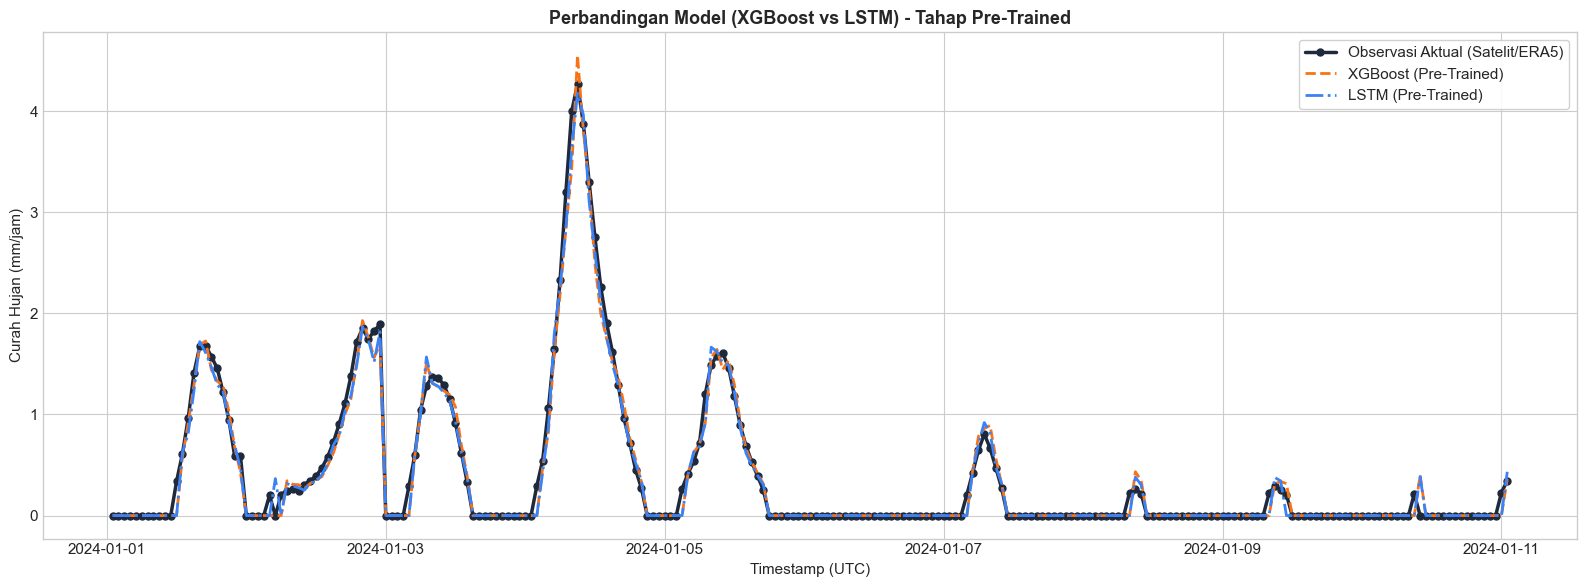

In [9]:
# A. Time-Series Tahap Pre-Trained (XGBoost vs LSTM)
plot_start = df_combined_pre.index.min()
plot_end = plot_start + pd.Timedelta(days=10)
plot_slice_pre = df_combined_pre[(df_combined_pre.index >= plot_start) & (df_combined_pre.index <= plot_end)]

plt.figure(figsize=(16, 6))
plt.plot(plot_slice_pre.index, plot_slice_pre['observed_pre'], label='Observasi Aktual (Satelit/ERA5)', color='#1e293b', marker='o', linewidth=2.5, markersize=5)
plt.plot(plot_slice_pre.index, plot_slice_pre['xgb_pred_reg_pre'], label='XGBoost (Pre-Trained)', color='#f97316', linestyle='--', linewidth=2.0)
plt.plot(plot_slice_pre.index, plot_slice_pre['lstm_pred_reg_pre'], label='LSTM (Pre-Trained)', color='#3b82f6', linestyle='-.', linewidth=2.0)
plt.title('Perbandingan Model (XGBoost vs LSTM) - Tahap Pre-Trained', fontsize=13, fontweight='bold')
plt.ylabel('Curah Hujan (mm/jam)')
plt.xlabel('Timestamp (UTC)')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

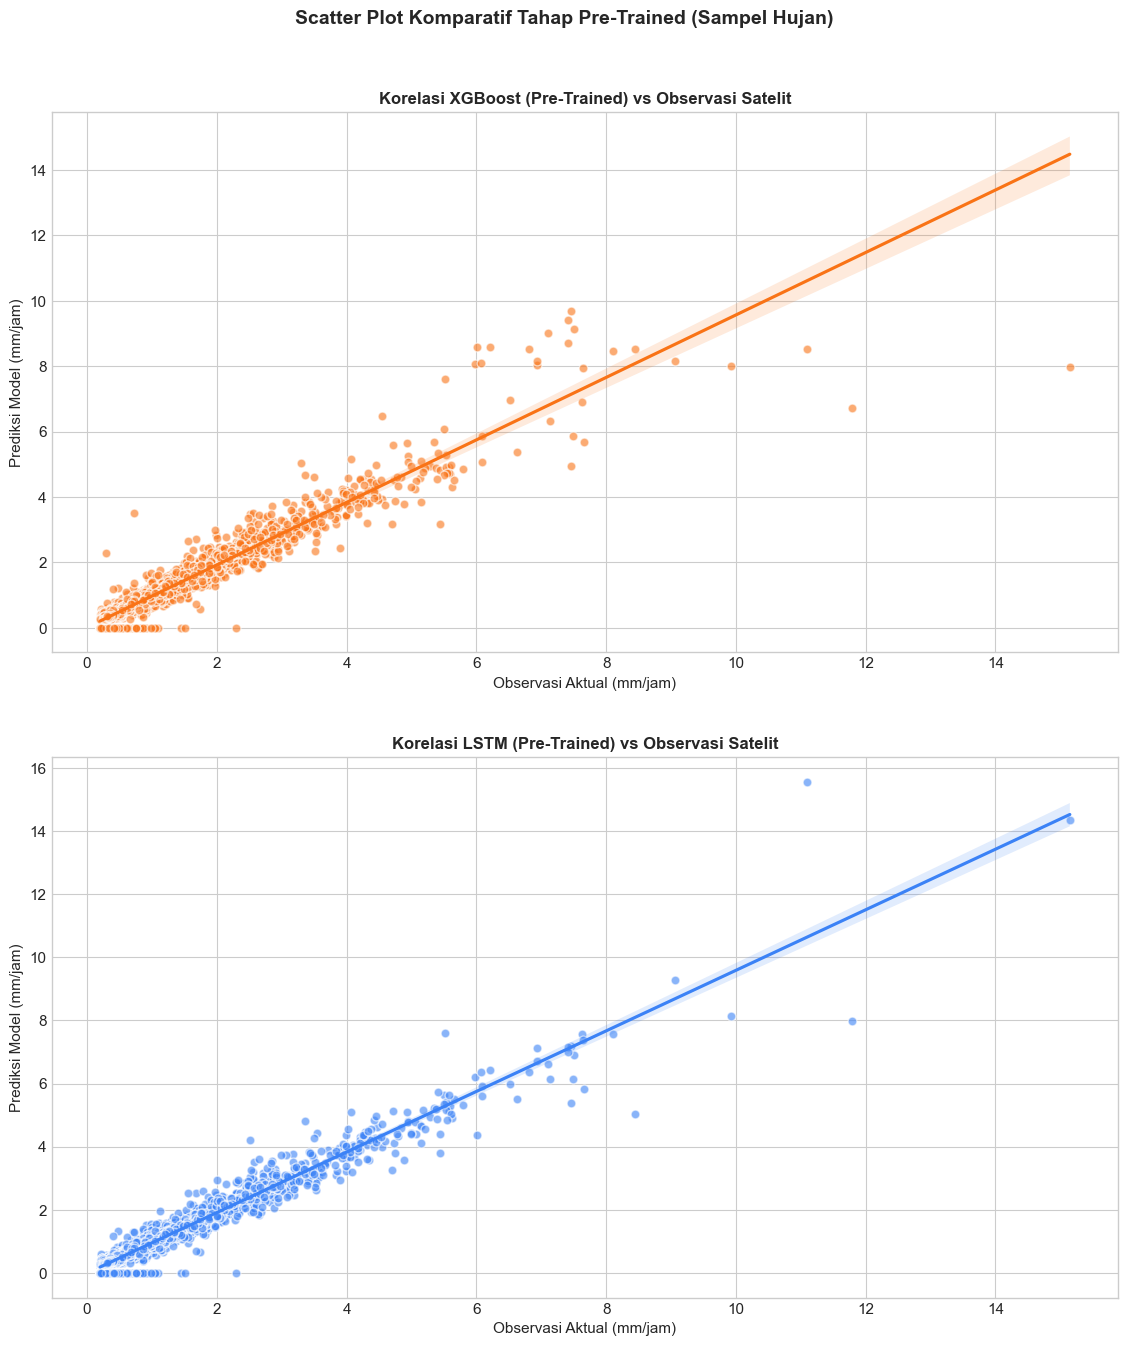

In [10]:
# B. Scatter Plot Korelasi Tahap Pre-Trained (XGBoost vs LSTM)
rainy_combined_pre = df_combined_pre[df_combined_pre['observed_pre'] >= 0.2]

fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# XGBoost Pre-Trained
sns.regplot(data=rainy_combined_pre, x='observed_pre', y='xgb_pred_reg_pre', ax=axes[0], color='#f97316', 
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 40})
axes[0].set_title('Korelasi XGBoost (Pre-Trained) vs Observasi Satelit', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Observasi Aktual (mm/jam)')
axes[0].set_ylabel('Prediksi Model (mm/jam)')

# LSTM Pre-Trained
sns.regplot(data=rainy_combined_pre, x='observed_pre', y='lstm_pred_reg_pre', ax=axes[1], color='#3b82f6', 
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 40})
axes[1].set_title('Korelasi LSTM (Pre-Trained) vs Observasi Satelit', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Observasi Aktual (mm/jam)')
axes[1].set_ylabel('Prediksi Model (mm/jam)')

plt.suptitle('Scatter Plot Komparatif Tahap Pre-Trained (Sampel Hujan)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(pad=3.0)
plt.show()

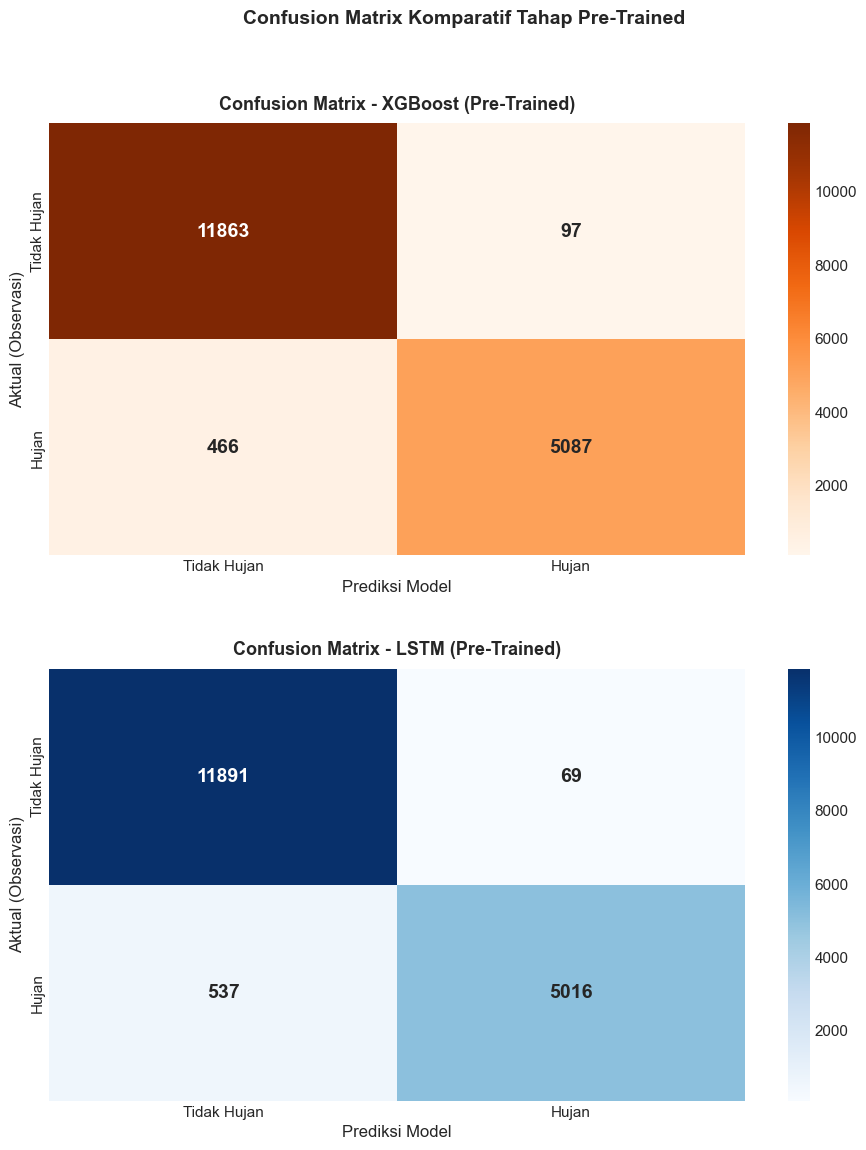

In [11]:
# C. Confusion Matrix Tahap Pre-Trained (XGBoost vs LSTM)
from sklearn.metrics import confusion_matrix
y_true_occ_pre = (df_combined_pre['observed_pre'] >= RAIN_THRESHOLD).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# XGBoost Pre-Trained
cm_xgb_pre = confusion_matrix(y_true_occ_pre, df_combined_pre['xgb_pred_occ_pre'])
sns.heatmap(cm_xgb_pre, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Tidak Hujan', 'Hujan'], yticklabels=['Tidak Hujan', 'Hujan'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix - XGBoost (Pre-Trained)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Aktual (Observasi)', fontsize=12)
axes[0].set_xlabel('Prediksi Model', fontsize=12)

# LSTM Pre-Trained
cm_lstm_pre = confusion_matrix(y_true_occ_pre, df_combined_pre['lstm_pred_occ_pre'])
sns.heatmap(cm_lstm_pre, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Tidak Hujan', 'Hujan'], yticklabels=['Tidak Hujan', 'Hujan'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix - LSTM (Pre-Trained)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Aktual (Observasi)', fontsize=12)
axes[1].set_xlabel('Prediksi Model', fontsize=12)

plt.suptitle('Confusion Matrix Komparatif Tahap Pre-Trained', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(pad=3.0)
plt.show()

## 5. Visualisasi & Evaluasi Tahap Fine-Tuned

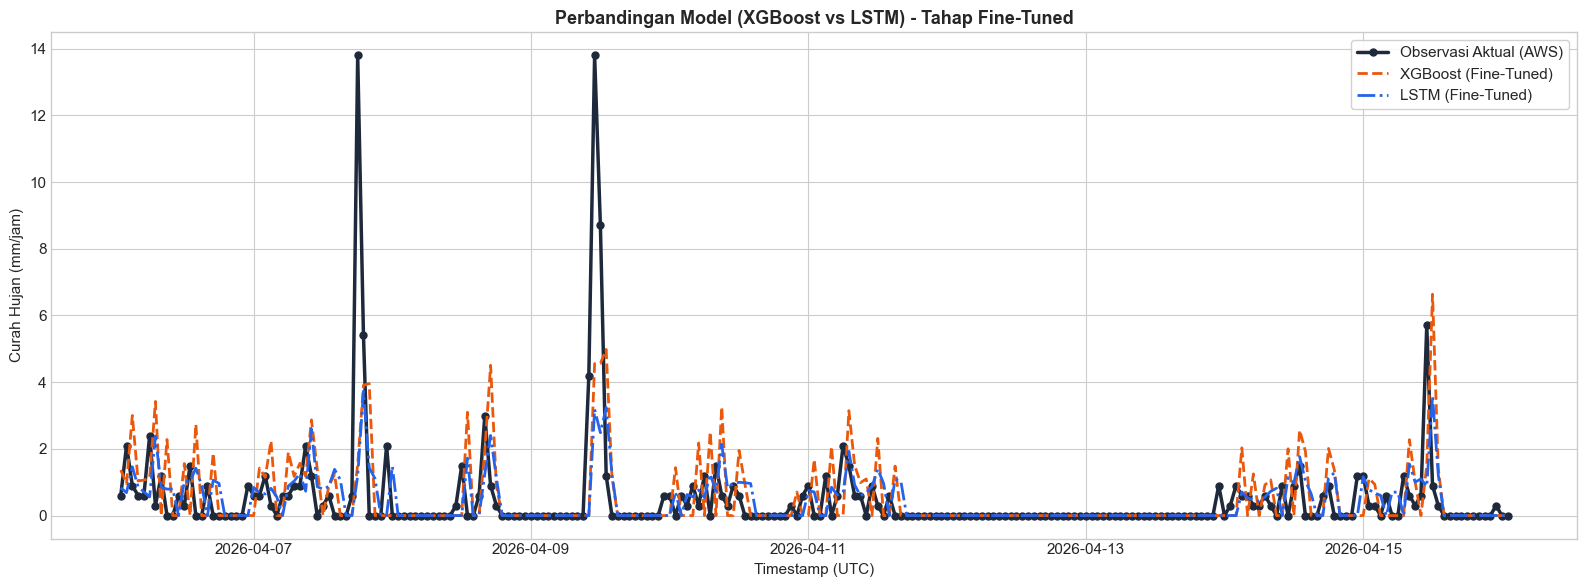

In [12]:
# A. Time-Series Tahap Fine-Tuned (XGBoost vs LSTM)
plot_start_fine = df_combined_fine.index.min()
plot_end_fine = plot_start_fine + pd.Timedelta(days=10)
plot_slice_fine = df_combined_fine[(df_combined_fine.index >= plot_start_fine) & (df_combined_fine.index <= plot_end_fine)]

plt.figure(figsize=(16, 6))
plt.plot(plot_slice_fine.index, plot_slice_fine['observed_aws'], label='Observasi Aktual (AWS)', color='#1e293b', marker='o', linewidth=2.5, markersize=5)
plt.plot(plot_slice_fine.index, plot_slice_fine['xgb_pred_reg_fine'], label='XGBoost (Fine-Tuned)', color='#ea580c', linestyle='--', linewidth=2.0)
plt.plot(plot_slice_fine.index, plot_slice_fine['lstm_pred_reg_fine'], label='LSTM (Fine-Tuned)', color='#2563eb', linestyle='-.', linewidth=2.0)
plt.title('Perbandingan Model (XGBoost vs LSTM) - Tahap Fine-Tuned', fontsize=13, fontweight='bold')
plt.ylabel('Curah Hujan (mm/jam)')
plt.xlabel('Timestamp (UTC)')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

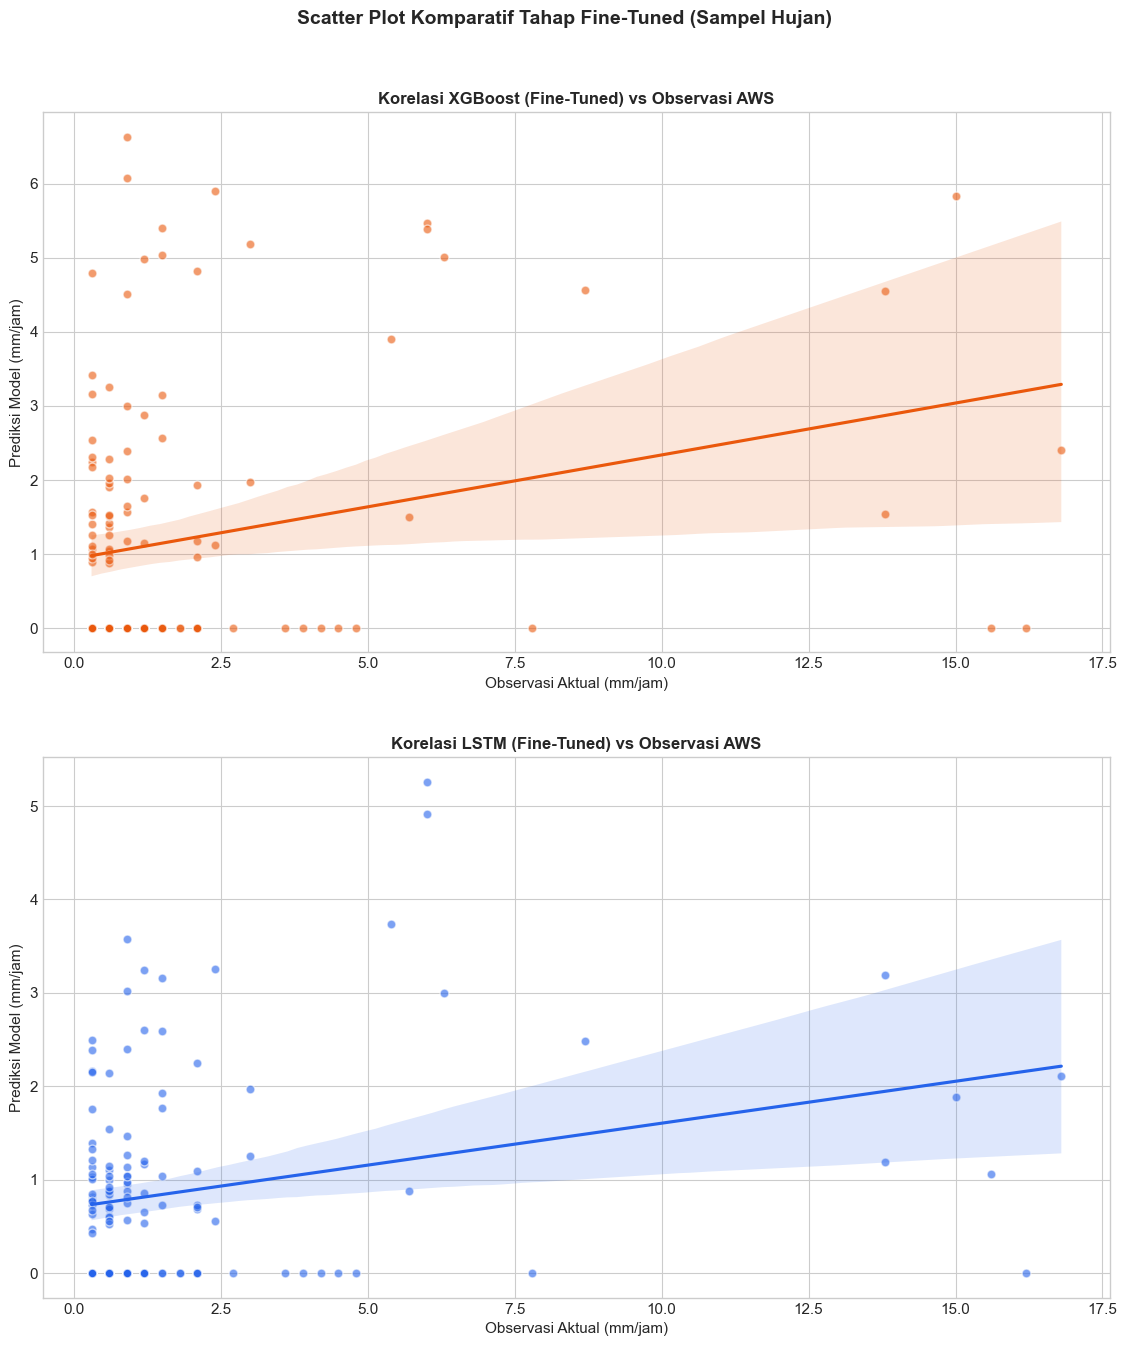

In [13]:
# B. Scatter Plot Korelasi Tahap Fine-Tuned (XGBoost vs LSTM)
rainy_combined_fine = df_combined_fine[df_combined_fine['observed_aws'] >= 0.2]

fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# XGBoost Fine-Tuned
sns.regplot(data=rainy_combined_fine, x='observed_aws', y='xgb_pred_reg_fine', ax=axes[0], color='#ea580c', 
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 40})
axes[0].set_title('Korelasi XGBoost (Fine-Tuned) vs Observasi AWS', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Observasi Aktual (mm/jam)')
axes[0].set_ylabel('Prediksi Model (mm/jam)')

# LSTM Fine-Tuned
sns.regplot(data=rainy_combined_fine, x='observed_aws', y='lstm_pred_reg_fine', ax=axes[1], color='#2563eb', 
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 40})
axes[1].set_title('Korelasi LSTM (Fine-Tuned) vs Observasi AWS', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Observasi Aktual (mm/jam)')
axes[1].set_ylabel('Prediksi Model (mm/jam)')

plt.suptitle('Scatter Plot Komparatif Tahap Fine-Tuned (Sampel Hujan)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(pad=3.0)
plt.show()

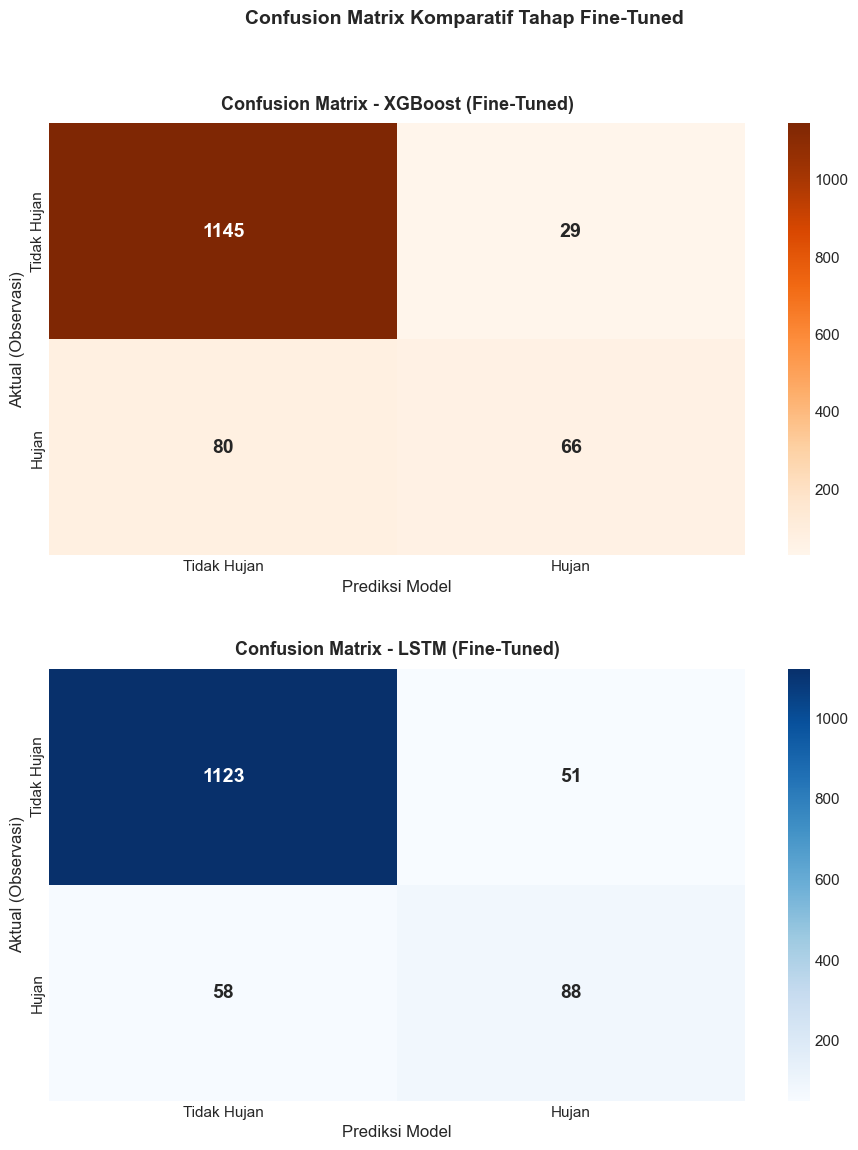

In [14]:
# C. Confusion Matrix Tahap Fine-Tuned (XGBoost vs LSTM)
y_true_occ_fine = (df_combined_fine['observed_aws'] >= RAIN_THRESHOLD).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# XGBoost Fine-Tuned
cm_xgb_fine = confusion_matrix(y_true_occ_fine, df_combined_fine['xgb_pred_occ_fine'])
sns.heatmap(cm_xgb_fine, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Tidak Hujan', 'Hujan'], yticklabels=['Tidak Hujan', 'Hujan'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix - XGBoost (Fine-Tuned)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Aktual (Observasi)', fontsize=12)
axes[0].set_xlabel('Prediksi Model', fontsize=12)

# LSTM Fine-Tuned
cm_lstm_fine = confusion_matrix(y_true_occ_fine, df_combined_fine['lstm_pred_occ_fine'])
sns.heatmap(cm_lstm_fine, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Tidak Hujan', 'Hujan'], yticklabels=['Tidak Hujan', 'Hujan'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix - LSTM (Fine-Tuned)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Aktual (Observasi)', fontsize=12)
axes[1].set_xlabel('Prediksi Model', fontsize=12)

plt.suptitle('Confusion Matrix Komparatif Tahap Fine-Tuned', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(pad=3.0)
plt.show()